<a href="https://colab.research.google.com/github/MariaPetrovskaya/Data-Science-for-HR/blob/main/Recruiter%E2%80%93Candidate%20Call%20Analytics%20(NLP%20R%26D)/New_Dialog_analytics_RND.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Project description

interview check list from customer

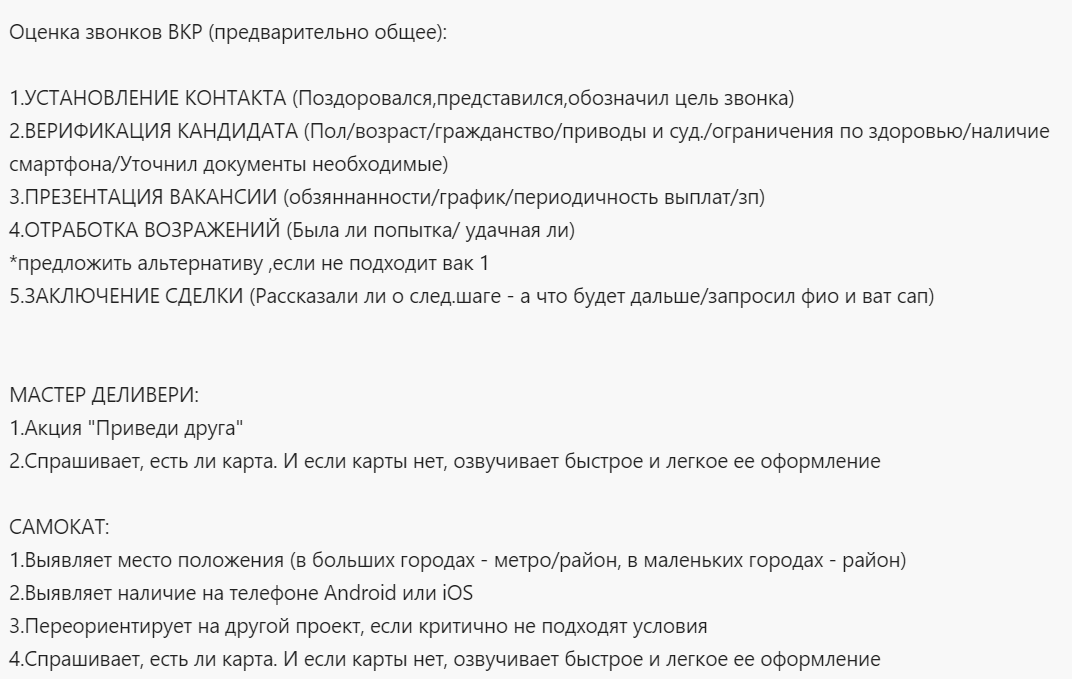

Список базовых вопросов по чек-листу заказчика
1. Как вас зовут
2. Ищете ли работу
3. В каком городе проживаете
4. Сколько вам лет
5. Гражданство РФ или нет
6. Есть ли судимости.

##Imports and installations

In [ ]:
import pandas as pd
import warnings
warnings.simplefilter('ignore')

import re

In [ ]:
import numpy as np

In [ ]:
from tqdm import notebook

In [ ]:
import plotly.express as px

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from datetime import date

In [ ]:
pip install pymorphy3


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 39.6 MB/s eta 0:00:00


In [ ]:
import pymorphy3

In [ ]:

import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
from pymorphy3 import MorphAnalyzer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:

  nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import names, stopwords, words

In [ ]:
from wordcloud import WordCloud, STOPWORDS

In [ ]:

nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:

from nltk.stem import WordNetLemmatizer


In [ ]:
from nltk.tokenize import WordPunctTokenizer

In [ ]:
# import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Загрузка стоп-слов (убираются высокочастотные слова, не несущие специфичного смысла)
#nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))

In [ ]:
import torch

In [ ]:
import json


In [ ]:
from json import loads, dumps

In [ ]:
!pip install phik

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 8.5 MB/s eta 0:00:00


In [ ]:
pd.options.mode.chained_assignment = None  # default='warn'
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
import phik

In [ ]:
from google.colab import drive
from google.colab import files
drive.mount('/content/drive')

Mounted at /content/drive


##Data load and preprocessing

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AI Eurasia /calls_transcription (1).csv')

In [ ]:

data = df.copy()
display (data.head(10))
print (data.info())
print (data.duplicated().sum())

,call_uuid,transcription
0,678de0b3-9dd6-4d05-94be-f9983d48ba9a,"[{""spk"": 1, ""text"": ""алло"", ""result"": [{""end"":..."
1,fc4d25c3-efea-4c35-8935-d152f9e9ba98,"[{""spk"": 1, ""text"": ""да"", ""result"": [{""end"": 1..."
2,8845035b-8198-4b4d-b180-89a142746987,"[{""spk"": 0, ""text"": ""алло здравствуйте меня зо..."
3,e02fad23-af86-4ee5-9e44-6ceb41c37e03,[]
4,0703a6be-a23a-49a2-b523-d85cb7f95f91,[]
5,e63b3277-0872-4850-b90c-92cbc8565ff4,"[{""spk"": 1, ""text"": ""алло здравствуйте"", ""resu..."
6,f86459ba-4cf4-4a85-aaca-076e906cf932,"[{""spk"": 1, ""text"": ""алло здравствуйте"", ""resu..."
7,2f2fab1d-748a-43a9-9237-2debccde6dcb,"[{""spk"": 1, ""text"": ""алло здравствуйте"", ""resu..."
8,3a127ae8-e687-48c6-9a79-1a9e1977a9bd,"[{""spk"": 0, ""text"": ""авита звонок по объявлени..."
9,7b6389f6-3779-417b-a535-713d5023e248,"[{""spk"": 0, ""text"": ""авито звонок по объявлени..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   call_uuid      26 non-null     object
 1   transcription  26 non-null     object
dtypes: object(2)
memory usage: 548.0+ bytes
None
0


In [ ]:
transcription1 = data.loc[25, 'transcription'] #big text loc in 0, 22

In [ ]:
print(transcription1)

[{"spk": 0, "text": " здравствуйте", "result": [{"end": 4.5, "part": "ГЛАГОЛ", "word": "здравствуйте", "lemma": "здравствовать", "start": 3.5}], "emotion": "speech", "emotion_audio": "neutral"}, {"spk": 0, "text": "меня зовут асельм", "result": [{"end": 5.5, "part": "МЕСТОИМЕНИЕ", "word": "меня", "lemma": "я", "start": 5.0}, {"end": 6.0, "part": "ГЛАГОЛ", "word": "зовут", "lemma": "звать", "start": 5.5}, {"end": 6.5, "part": "СУЩЕСТВИТЕЛЬНОЕ", "word": "асельм", "lemma": "асельм", "start": 6.0}], "emotion": "neutral", "emotion_audio": "neutral"}, {"spk": 1, "text": "дравс", "result": [{"end": 6.4, "part": "unk", "word": "дравс", "lemma": "дравс", "start": 6.0}], "emotion": "skip", "emotion_audio": "neutral"}, {"spk": 0, "text": "официальным партнером компании лента вы откликались на вакансию сборщик заказов подскажите актуальна вакансия для вас", "result": [{"end": 7.133333333333334, "part": "ПРИЛАГАТЕЛЬНОЕ", "word": "официальным", "lemma": "официальный", "start": 6.7}, {"end": 7.566666

In [ ]:
transcription1

'[{"spk": 0, "text": " здравствуйте", "result": [{"end": 4.5, "part": "ГЛАГОЛ", "word": "здравствуйте", "lemma": "здравствовать", "start": 3.5}], "emotion": "speech", "emotion_audio": "neutral"}, {"spk": 0, "text": "меня зовут асельм", "result": [{"end": 5.5, "part": "МЕСТОИМЕНИЕ", "word": "меня", "lemma": "я", "start": 5.0}, {"end": 6.0, "part": "ГЛАГОЛ", "word": "зовут", "lemma": "звать", "start": 5.5}, {"end": 6.5, "part": "СУЩЕСТВИТЕЛЬНОЕ", "word": "асельм", "lemma": "асельм", "start": 6.0}], "emotion": "neutral", "emotion_audio": "neutral"}, {"spk": 1, "text": "дравс", "result": [{"end": 6.4, "part": "unk", "word": "дравс", "lemma": "дравс", "start": 6.0}], "emotion": "skip", "emotion_audio": "neutral"}, {"spk": 0, "text": "официальным партнером компании лента вы откликались на вакансию сборщик заказов подскажите актуальна вакансия для вас", "result": [{"end": 7.133333333333334, "part": "ПРИЛАГАТЕЛЬНОЕ", "word": "официальным", "lemma": "официальный", "start": 6.7}, {"end": 7.56666

In [ ]:
# import json
# # инициализируем строковое представление списка
# initial_list = "[11, 21, 19, 46, 29]"
# # выведем нужную нам строку и убедимся что это именно строка
# print("initial string", initial_list)
# print(type(initial_list))
# преобразуем строку в список
op = json.loads(transcription1)
# выведем результат
# print("final list", op)
# print(type(op))

In [ ]:
op

[{'spk': 0,
  'text': ' здравствуйте',
  'result': [{'end': 4.5,
    'part': 'ГЛАГОЛ',
    'word': 'здравствуйте',
    'lemma': 'здравствовать',
    'start': 3.5}],
  'emotion': 'speech',
  'emotion_audio': 'neutral'},
 {'spk': 0,
  'text': 'меня зовут асельм',
  'result': [{'end': 5.5,
    'part': 'МЕСТОИМЕНИЕ',
    'word': 'меня',
    'lemma': 'я',
    'start': 5.0},
   {'end': 6.0,
    'part': 'ГЛАГОЛ',
    'word': 'зовут',
    'lemma': 'звать',
    'start': 5.5},
   {'end': 6.5,
    'part': 'СУЩЕСТВИТЕЛЬНОЕ',
    'word': 'асельм',
    'lemma': 'асельм',
    'start': 6.0}],
  'emotion': 'neutral',
  'emotion_audio': 'neutral'},
 {'spk': 1,
  'text': 'дравс',
  'result': [{'end': 6.4,
    'part': 'unk',
    'word': 'дравс',
    'lemma': 'дравс',
    'start': 6.0}],
  'emotion': 'skip',
  'emotion_audio': 'neutral'},
 {'spk': 0,
  'text': 'официальным партнером компании лента вы откликались на вакансию сборщик заказов подскажите актуальна вакансия для вас',
  'result': [{'end': 7.1333

In [ ]:
calldata=pd.json_normalize(op)

In [ ]:
# calldata

In [ ]:
exploded_df = calldata.explode("result",ignore_index = True)

In [ ]:
exploded_df

,spk,text,result,emotion,emotion_audio
0,0,здравствуйте,"{'end': 4.5, 'part': 'ГЛАГОЛ', 'word': 'здравс...",speech,neutral
1,0,меня зовут асельм,"{'end': 5.5, 'part': 'МЕСТОИМЕНИЕ', 'word': 'м...",neutral,neutral
2,0,меня зовут асельм,"{'end': 6.0, 'part': 'ГЛАГОЛ', 'word': 'зовут'...",neutral,neutral
3,0,меня зовут асельм,"{'end': 6.5, 'part': 'СУЩЕСТВИТЕЛЬНОЕ', 'word'...",neutral,neutral
4,1,дравс,"{'end': 6.4, 'part': 'unk', 'word': 'дравс', '...",skip,neutral
...,...,...,...,...,...
378,0,хорошо,"{'end': 200.7, 'part': 'ПРИЛАГАТЕЛЬНОЕ', 'word...",positive,neutral
379,0,всего доброго до свидания,"{'end': 201.425, 'part': 'МЕСТОИМЕНИЕ', 'word'...",speech,positive
380,0,всего доброго до свидания,"{'end': 201.75, 'part': 'ПРИЛАГАТЕЛЬНОЕ', 'wor...",speech,positive
381,0,всего доброго до свидания,"{'end': 202.075, 'part': 'ПРЕДЛОГ', 'word': 'д...",speech,positive


In [ ]:
# exploded_df.info()

In [ ]:
result_data =pd.json_normalize(exploded_df['result'])

In [ ]:
result_data

,end,part,word,lemma,start
0,4.500,ГЛАГОЛ,здравствуйте,здравствовать,3.500
1,5.500,МЕСТОИМЕНИЕ,меня,я,5.000
2,6.000,ГЛАГОЛ,зовут,звать,5.500
3,6.500,СУЩЕСТВИТЕЛЬНОЕ,асельм,асельм,6.000
4,6.400,unk,дравс,дравс,6.000
...,...,...,...,...,...
378,200.700,ПРИЛАГАТЕЛЬНОЕ,хорошо,хороший,200.300
379,201.425,МЕСТОИМЕНИЕ,всего,всего,201.100
380,201.750,ПРИЛАГАТЕЛЬНОЕ,доброго,добрый,201.425
381,202.075,ПРЕДЛОГ,до,до,201.750


In [ ]:
# print(result_data.index)


In [ ]:
# result_data.set_index(keys='end', inplace=True)

In [ ]:
# exploded_df.set_index(keys='result', inplace=True)

In [ ]:
# result_data.info()

In [ ]:
# exploded_df.info()

In [ ]:
# result_data.set_index(keys='end', inplace=True)

In [ ]:
# allcalldata = pd.merge(exploded_df, result_data, how="left", on=["end"].)
allcalldata = pd.concat([exploded_df, result_data], axis=1, ignore_index=False)

In [ ]:
# allcalldata.info()

In [ ]:
# allcalldata

In [ ]:
allcalldata = allcalldata.drop(['result'], axis=1)

In [ ]:
# allcalldata.head(10)

In [ ]:
# allcalldata.tail(10)

In [ ]:
allcalldata.sample(10)

,spk,text,emotion,emotion_audio,end,part,word,lemma,start
373,0,тогда если вдруг все таки два раза в месяц вам...,neutral,neutral,196.333333,СОЮЗ,либо,либо,195.966667
77,0,основная обязанность сборщика заказов это соби...,neutral,neutral,45.544444,ГЛАГОЛ,относите,относить,45.125926
215,0,также вы можете пригласить к нам друга на рабо...,neutral,neutral,107.000000,СУЩЕСТВИТЕЛЬНОЕ,рублей,рубль,106.676923
51,1,двадцать три российскоя федерация,neutral,neutral,32.950000,ГЛАГОЛ,российскоя,российскоя,32.600000
53,0,хорошо,positive,positive,35.100000,ПРИЛАГАТЕЛЬНОЕ,хорошо,хороший,34.200000
243,0,так видимо наверное какая то ошибка я обязател...,neutral,neutral,120.700000,МЕСТОИМЕНИЕ,ней,она,120.390000
25,0,тогда задам пару вопросов по анкете далее подр...,neutral,neutral,20.172727,НАРЕЧИЕ,тогда,тогда,19.800000
101,0,во время работы будет времяна обед и перерыв,neutral,neutral,56.100000,СУЩЕСТВИТЕЛЬНОЕ,обед,обед,55.750000
362,0,тогда если вдруг все таки два раза в месяц вам...,neutral,neutral,192.300000,unk,два,два,191.933333
355,0,поняла хорошо,neutral,neutral,189.200000,ГЛАГОЛ,поняла,понять,188.500000


###Result to dataset

In [ ]:
data_rec = allcalldata.loc[allcalldata['spk'] == 0]

In [ ]:
data_rec.info()

<class 'pandas.core.frame.DataFrame'>
Index: 325 entries, 0 to 382
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   spk            325 non-null    int64  
 1   text           325 non-null    object 
 2   emotion        325 non-null    object 
 3   emotion_audio  325 non-null    object 
 4   end            325 non-null    float64
 5   part           325 non-null    object 
 6   word           325 non-null    object 
 7   lemma          325 non-null    object 
 8   start          325 non-null    float64
dtypes: float64(2), int64(1), object(6)
memory usage: 25.4+ KB


отдельный датасет с записями только рекрутера

In [ ]:
data_apl = allcalldata.loc[allcalldata['spk'] == 1]

In [ ]:
data_apl.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58 entries, 4 to 354
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   spk            58 non-null     int64  
 1   text           58 non-null     object 
 2   emotion        58 non-null     object 
 3   emotion_audio  58 non-null     object 
 4   end            58 non-null     float64
 5   part           58 non-null     object 
 6   word           58 non-null     object 
 7   lemma          58 non-null     object 
 8   start          58 non-null     float64
dtypes: float64(2), int64(1), object(6)
memory usage: 4.5+ KB


отдельный датасет с записями только кандидата

##Recruiter check list

###Выделение тем простым алгоритмом и демо стимера


In [ ]:
data=data_rec.copy()

In [ ]:
# -*- coding: utf-8 -*-
# Портирован с Java по мотивам http://www.algorithmist.ru/2010/12/porter-stemmer-russian.html
import re

class Porter:
	PERFECTIVEGROUND =  re.compile(u"((ив|ивши|ившись|ыв|ывши|ывшись)|((?<=[ая])(в|вши|вшись)))$")
	REFLEXIVE = re.compile(u"(с[яь])$")
	ADJECTIVE = re.compile(u"(ее|ие|ые|ое|ими|ыми|ей|ий|ый|ой|ем|им|ым|ом|его|ого|ему|ому|их|ых|ую|юю|ая|яя|ою|ею)$")
	PARTICIPLE = re.compile(u"((ивш|ывш|ующ)|((?<=[ая])(ем|нн|вш|ющ|щ)))$")
	VERB = re.compile(u"((ила|ыла|ена|ейте|уйте|ите|или|ыли|ей|уй|ил|ыл|им|ым|ен|ило|ыло|ено|ят|ует|уют|ит|ыт|ены|ить|ыть|ишь|ую|ю)|((?<=[ая])(ла|на|ете|йте|ли|й|л|ем|н|ло|но|ет|ют|ны|ть|ешь|нно)))$")
	NOUN = re.compile(u"(а|ев|ов|ие|ье|е|иями|ями|ами|еи|ии|и|ией|ей|ой|ий|й|иям|ям|ием|ем|ам|ом|о|у|ах|иях|ях|ы|ь|ию|ью|ю|ия|ья|я)$")
	RVRE = re.compile(u"^(.*?[аеиоуыэюя])(.*)$")
	DERIVATIONAL = re.compile(u".*[^аеиоуыэюя]+[аеиоуыэюя].*ость?$")
	DER = re.compile(u"ость?$")
	SUPERLATIVE = re.compile(u"(ейше|ейш)$")
	I = re.compile(u"и$")
	P = re.compile(u"ь$")
	NN = re.compile(u"нн$")

	def stem(word):
		word = word.lower()
		word = word.replace(u'ё', u'е')
		m = re.match(Porter.RVRE, word)
		if m.groups():
			pre = m.group(1)
			rv = m.group(2)
			temp = Porter.PERFECTIVEGROUND.sub('', rv, 1)
			if temp == rv:
				rv = Porter.REFLEXIVE.sub('', rv, 1)
				temp = Porter.ADJECTIVE.sub('', rv, 1)
				if temp != rv:
					rv = temp
					rv = Porter.PARTICIPLE.sub('', rv, 1)
				else:
					temp = Porter.VERB.sub('', rv, 1)
					if temp == rv:
						rv = Porter.NOUN.sub('', rv, 1)
					else:
						rv = temp
			else:
				rv = temp

			rv = Porter.I.sub('', rv, 1)

			if re.match(Porter.DERIVATIONAL, rv):
				rv = Porter.DER.sub('', rv, 1)

			temp = Porter.P.sub('', rv, 1)
			if temp == rv:
				rv = Porter.SUPERLATIVE.sub('', rv, 1)
				rv = Porter.NN.sub(u'н', rv, 1)
			else:
				rv = temp
			word = pre+rv
		return word
	stem=staticmethod(stem)

# if __name__ == '__main__':
#     print Porter.stem(u'устойчивость')


In [ ]:
Porter.stem('выгода')

'выгод'

стимер помогает найти оптимальный набор символов для поиска (стеммизация — процесс приведения слова к его корню/основе)здесь работает как подсказка в ручном режиме, в других реализациях добавляется в алгоритм

In [ ]:
data['text'] = data['text'].str.lower()
data['text'] = data['text'] .str.replace('ё', 'е')

###Check list full version

In [ ]:
#вариант 1 собирательный фильтр на все упоминавщиеся в чек-листе категории

data['job_cat'] = None
data.loc[(data['text'].str.contains('здравств', case=True))\
           |(data['text'].str.contains('привет',case=True))\
           |(data['text'].str.contains('добрый день',case=False)), 'job_cat'] = 'Поздоровался'

data.loc[(data['text'].str.contains('резидент', case=True))\
           |(data['text'].str.contains('граждан', case=True)), 'job_cat'] = 'Гражданство'

data.loc [(data['text'].str.contains('лет', case=False))\
           |(data['text'].str.contains('рождения',case=False))\
           |(data['text'].str.contains('возраст',case=True))\
           |(data['text'].str.contains('совершеннолет',case=True)), 'job_cat'] = 'Возраст'

data.loc [(data['text'].str.contains('здоров', case=True))\
           |(data['text'].str.contains('заболеван',case=True))\
           |(data['text'].str.contains('инвалидн',case=True))\
           |(data['text'].str.contains('болезн',case=True)), 'job_cat'] = 'Здоровье'

data.loc[(data['text'].str.contains('плат', case=True))\
           |(data['text'].str.contains('ставк',case=True))\
           |(data['text'].str.contains('оплат',case=True))\
           |(data['text'].str.contains('зарплат',case=True))\
           |(data['text'].str.contains('заработок',case=False))\
           |(data['text'].str.contains('доход',case=True))\
           |(data['text'].str.contains('деньг',case=True))\
           |(data['text'].str.contains('рубл',case=True)), 'job_cat'] = 'Зарплата'

data.loc[(data['text'].str.contains('офомл', case=True))\
           |(data['text'].str.contains('паспорт', case=True))\
           |(data['text'].str.contains('трудовая книжка', case=False))\
           |(data['text'].str.contains('контракт', case=True))\
           |(data['text'].str.contains('договор',case=True))\
           |(data['text'].str.contains('гпх',case=False))\
           |(data['text'].str.contains('самозанят',case=True)),'job_cat'] = 'Оформление'


data.loc[(data['text'].str.contains('вечер',case=True))\
           |(data['text'].str.contains('утр',case=True))\
           |(data['text'].str.contains('ден',case=True))\
           |(data['text'].str.contains('вахт',case=True))\
           |(data['text'].str.contains('смен',case=True))\
           |(data['text'].str.contains('сменный',case=True))\
           |(data['text'].str.contains('нача',case=True))\
           |(data['text'].str.contains('конец',case=True)), 'job_cat'] = 'Рабочее время'

data.loc[(data['text'].str.contains('стаж', case=True))\
          |(data['text'].str.contains('опыт', case=True))\
          |(data['text'].str.contains('квалификац', case=True))\
          |(data['text'].str.contains('работали', case=False))\
          |(data['text'].str.contains('навык',case=True))\
          |(data['text'].str.contains('умеете',case=False))\
          |(data['text'].str.contains('разряд',case=True))\
          |(data['text'].str.contains('сертификат',case=True))\
          |(data['text'].str.contains('диплом',case=True)), 'job_cat'] = 'Квалификация'

data.loc[(data['text'].str.contains('фамил', case=True))\
           |(data['text'].str.contains('представьт',case=True))\
           |(data['text'].str.contains('отчеств',case=True))\
           |(data['text'].str.contains('имя',case=True))\
           |(data['text'].str.contains('зовут',case=True)), 'job_cat'] = 'ФИО'

data.loc[(data['text'].str.contains('город', case=True))\
           |(data['text'].str.contains('метро', case=False))\
           |(data['text'].str.contains('улиц', case=True))\
           |(data['text'].str.contains('район',case=True)), 'job_cat'] = 'Место'

data.loc[(data['text'].str.contains('контакт', case=True))\
           |(data['text'].str.contains('телеграм',case=True))\
           |(data['text'].str.contains('ватсап', case=False))\
           |(data['text'].str.contains('связаться', case=False))\
           |(data['text'].str.contains('телефон', case=True))\
           |(data['text'].str.contains('мейл', case=False))\
           |(data['text'].str.contains('чат', case=False))\
           |(data['text'].str.contains('вайбер', case=False))\
           |(data['text'].str.contains('почт', case=True))\
           |(data['text'].str.contains('звон', case=True)), 'job_cat'] = 'Контакт'

data.loc[(data['text'].str.contains('компан', case=True))\
            |(data['text'].str.contains('ваканс',case=True))\
            |(data['text'].str.contains('работ',case=True))\
            |(data['text'].str.contains('позиц',case=True))\
            |(data['text'].str.contains('должност',case=True)), 'job_cat'] = 'Описание'


data.loc[(data['text'].str.contains('андроид', case=True))\
            |(data['text'].str.contains('айфон',case=True))\
            |(data['text'].str.contains('сматфон',case=True))\
            |(data['text'].str.contains('android',case=False))\
            |(data['text'].str.contains('ios',case=False)), 'job_cat'] = 'Cмартфон'


data.loc[(data['text'].str.contains('уголовн', case=True))\
            |(data['text'].str.contains('привлекались',case=False))\
            |(data['text'].str.contains('осужден',case=True))\
            |(data['text'].str.contains('судим',case=True)), 'job_cat'] = 'Cудимость'

data.loc[(data['text'].str.contains('преимуществ', case=True))\
            |(data['text'].str.contains('достоинств',case=True))\
            |(data['text'].str.contains('выгод',case=True))\
            |(data['text'].str.contains('бонус',case=True)), 'job_cat'] = 'Возражения'


data.loc[(data['text'].str.contains('рекрутер', case=False))\
           |(data['text'].str.contains('recruiter',case=False))\
           |(data['text'].str.contains('ресечер',case=True))\
           |(data['text'].str.contains('рисерчер',case=True))\
           |(data['text'].str.contains('персонал',case=True))\
           |(data['text'].str.contains('карьер',case=True))\
           |(data['text'].str.contains('hr',case=False))\
           |(data['text'].str.contains('career',case=False))\
           |(data['text'].str.contains('сорсер',case=True)), 'job_cat'] = 'HR'

data['job_cat'] = data['job_cat'].fillna('Другое')

case=False когда в поиске это не может быть вхождение а другое слово, а дожно быть отделено пробелами

In [ ]:
fig = px.histogram(data,
                     x= 'job_cat',
                     histnorm='percent',
                     title='Распределение диалога по темам (категориям), простой алгоритм ',
                     text_auto = True)
fig.update_layout(yaxis_title_text = '% вакансий этой категории',
                  xaxis_title_text = 'Категория',
                  xaxis = {"categoryorder":"total descending"})
fig.update_traces(texttemplate='%{y:.2f}%')
fig.show()

так мы можем убедиться, что темы из чек-листа присутствовали в диалоге

In [ ]:
print(data['job_cat'].value_counts())
# print(data['name'].value_counts())

job_cat
Другое           72
Описание         71
Зарплата         69
Контакт          48
Возражения       26
Рабочее время    22
Возраст           7
Место             6
ФИО               3
Поздоровался      1
Name: count, dtype: int64


In [ ]:
data_offtop = data.loc[data['job_cat'] == 'Другое']
# data_ds = data.loc[data['platform'] == 'DS']

In [ ]:
data_offtop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72 entries, 21 to 382
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   spk            72 non-null     int64  
 1   text           72 non-null     object 
 2   emotion        72 non-null     object 
 3   emotion_audio  72 non-null     object 
 4   end            72 non-null     float64
 5   part           72 non-null     object 
 6   word           72 non-null     object 
 7   lemma          72 non-null     object 
 8   start          72 non-null     float64
 9   job_cat        72 non-null     object 
dtypes: float64(2), int64(1), object(7)
memory usage: 6.2+ KB


###Расчет метрики оценки интервью

In [ ]:
datalen = len(data['job_cat'])
print(datalen)

325


In [ ]:
offtop = len(data.loc[data['job_cat'] == 'Другое'])
print(offtop)

72


In [ ]:
totalrange = round(10*((datalen-offtop)/datalen))
print(totalrange)


8


In [ ]:
# totalrange = round(10*((datalen-offtop)/datalen))
# print(totalrange)
if totalrange < 5:
    print ('alert! ALERT!!!!')
if totalrange >= 5:
    print ('good result')

good result


###Check list short version

этот раздел если будет сокращенная версия фильтра, пока пустой

##All Speech Data EDA

In [ ]:
df_hy=allcalldata.copy()

In [ ]:
df_hy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   spk            383 non-null    int64  
 1   text           383 non-null    object 
 2   emotion        383 non-null    object 
 3   emotion_audio  383 non-null    object 
 4   end            383 non-null    float64
 5   part           383 non-null    object 
 6   word           383 non-null    object 
 7   lemma          383 non-null    object 
 8   start          383 non-null    float64
dtypes: float64(2), int64(1), object(6)
memory usage: 27.1+ KB


In [ ]:
print ('суммарная продолжительность разговора', round(df_hy['end'].max()- df_hy['start'].min()), "секунд")

суммарная продолжительность разговора 199 секунд


In [ ]:
job_description = []
for elem in df_hy['text'].unique():
    if ('компани') in elem:
        job_description.append(elem)
#df[df['employee_qty'].isin(applicants)][['employee_qty', 'applicants']]

In [ ]:
display(job_description)

['официальным партнером компании лента вы откликались на вакансию сборщик заказов подскажите актуальна вакансия для вас']

In [ ]:
# print(df_hy[(~df_hy.text.str.contains('вакан',na=True))
#   &(~df_hy.text.str.contains('работ',na=True))]['text'].unique)

**Транскрибатор сейчас может размечать эмоции в текстах на основании звука и на основании состава слов**. Посмотрим подробнее - коррелируют ли эти признаки? Есть ли корреляция между собой и закономерность по спикеру

interval columns not set, guessing: ['spk']


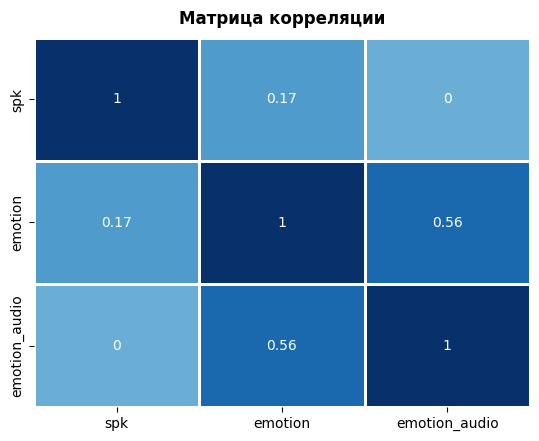

In [ ]:
# Построим heatmap для изучение корреляции
sns.heatmap(df_hy[['spk', 'emotion', 'emotion_audio']].phik_matrix(),
            annot=True, vmin=-1, vmax=1, center=0, cmap='Blues', linewidths=1, cbar=False)
plt.title('Матрица корреляции', fontsize=12, fontweight='bold', pad=10)
plt.xticks(rotation=0)
plt.show();

In [ ]:
print(df_hy['emotion'].value_counts())

emotion
neutral     370
positive      7
speech        5
skip          1
Name: count, dtype: int64


In [ ]:
print(df_hy['emotion_audio'].value_counts())

emotion_audio
neutral     374
positive      5
sad           4
Name: count, dtype: int64


**Рассмотрим соотошение речевой активности рекрутера и кандидата.** Рабочая гипотеза - есть нормальное сообнощения, **например 60 рукрутер/40 кандидат**. Можно посчитать на успешных кейсах. Гипотеза, что как слишком высокая, так и слишком низкая активность рекрутера - маркер нездорового процесса

In [ ]:
fig = px.histogram(df_hy,
                     x= 'spk',
                     histnorm='percent',
                     title='соотношение речевой активности рекрутера и кандидата',
                     text_auto = True)
fig.update_layout(yaxis_title_text = 'Количество реплик',
                  xaxis_title_text = 'Участник',
                  xaxis = {"categoryorder":"total descending"})
fig.update_traces(texttemplate='%{y:.2f}%')
fig.show()

**Трансрибатор умеет определять части речи**. Пока вижу в этом только то практическое применение, что **хорошей агитационной речью считается речь с большим количеством глаголов**. Посмотрим соотношение частей речи **только у рекрутера**


In [ ]:
fig = px.histogram(data_rec,
                     x= 'part',
                     histnorm='percent',
                     title='соотношение частей речи в текстах рекрутера',
                     text_auto = True)
fig.update_layout(yaxis_title_text = 'Процент',
                  xaxis_title_text = 'Части речи',
                  xaxis = {"categoryorder":"total descending"})
fig.update_traces(texttemplate='%{y:.2f}%')
fig.show()

##Word2Vec

Векторная визуализация, "облако слов"

In [ ]:
new_clear_data = allcalldata.copy()

In [ ]:
new_clear = pd.DataFrame(data=new_clear_data)

In [ ]:
new_clear.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   spk            383 non-null    int64  
 1   text           383 non-null    object 
 2   emotion        383 non-null    object 
 3   emotion_audio  383 non-null    object 
 4   end            383 non-null    float64
 5   part           383 non-null    object 
 6   word           383 non-null    object 
 7   lemma          383 non-null    object 
 8   start          383 non-null    float64
dtypes: float64(2), int64(1), object(6)
memory usage: 27.1+ KB


####Функции для предварительной обработки текста (Text preprocessing)

In [ ]:
# Функция для лемматизации слов - слова заменяются на основную словоформу
def lemmatize_words(text, morph):
    words = word_tokenize(text)
    lemmatized_words = [morph.parse(word)[0].normal_form for word in words]
    return ' '.join(lemmatized_words)

In [ ]:
# set regular expressions for text preprocessing
HTML = r'<.*?>' # html tags
COMMENTS = r'[\(\[][A-Za-z ]+[\)\]]' # comments in parentheses
LETTERS = r'[^\w\s]+[а-яА-Я]' #any letter
SPACES = r'([ ])\1+' # repeated spaces
DOTS = r'[\.]+' # punctuation mark ellipsis
SYMB = r"[^\w\d'\s]" # punctuation marks other than apostrophe

In [ ]:

def dataset_clean(x, nan_value= None):
    for column in x:
        txt = re.sub(HTML, ' ', x) # html tags change to spaces
        #txt = re.sub(COMMENTS, ' ', txt) # comments in parentheses change to spaces
        #txt = re.sub(LETTERS, ' ', txt) # anything that isn't a letter is a space
        txt = re.sub(DOTS, r'.', txt) # punctuation mark ellipsis change to dots
        txt = re.sub(SPACES, r'\1', txt) # repeated spaces change to one space
        #txt = re.sub(SYMB, '', txt) # punctuation marks other than apostrophe change to an empty string
        txt = re.sub('_x000d_', '', txt) # 'www' change to an empty string
        #txt = txt.lstrip().rstrip().replace("\n","") # left space trimming
        #txt = txt.encode('ascii', 'ignore').decode() # remove all non-ascii characters
        #txt = txt.lower() # to lowercase
        txt = ' '.join(txt.split())
    return txt

In [ ]:
# Создадим функцию для построения облака слов
def function_worldcloud(text):
  wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(text)
  plt.figure(figsize=(10, 8))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.show()

In [ ]:
# Инициализация стоп-слов
stop_words = set(stopwords.words('russian'))

# Добавление собственных вариантов к списку стоп-слов
custom_stop_words = set(['работа', 'работать'])

# Объединение стандартных и собственных стоп-слов
stop_words = stop_words.union(custom_stop_words)

# Инициализация лемматизатора и морфологического анализатора
morph = pymorphy3.MorphAnalyzer()#(AttributeError: module 'inspect' has no attribute 'getargspec')
lemmatizer = WordNetLemmatizer()

# Функция для токенизации, лемматизации и удаления стоп-слов
def tokenize_lemmatize_and_filter(text):
    tokens = word_tokenize(text)
    lemmatized_tokens = [lemmatizer.lemmatize(morph.parse(token)[0].normal_form) for token in tokens]
    return [token for token in lemmatized_tokens if token.lower() not in stop_words and token.isalpha()]

# Функция для создания и отображения облака слов
def WC(text):
    wordcloud = WordCloud(background_color='white', repeat=False, width=800, height=600).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    return plt.show()

In [ ]:
def get_words_dict(words): #функция словаря
    words_dict = dict()

    for word in words:
        if word in words_dict:
            words_dict[word] = words_dict[word] + 1
        else:
            words_dict[word] = 1
    return words_dict

####"Облако слов" для всех текстовых полей


In [ ]:
new_clear.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   spk            383 non-null    int64  
 1   text           383 non-null    object 
 2   emotion        383 non-null    object 
 3   emotion_audio  383 non-null    object 
 4   end            383 non-null    float64
 5   part           383 non-null    object 
 6   word           383 non-null    object 
 7   lemma          383 non-null    object 
 8   start          383 non-null    float64
dtypes: float64(2), int64(1), object(6)
memory usage: 27.1+ KB


In [ ]:
print('Количество пропусков: ',new_clear['text'].isna().sum())

Количество пропусков:  0


In [ ]:
# new_clear['text']= new_clear['text'].fillna('или')
# #на случай если пропуски будут

In [ ]:
new_clear['text'].astype(str)

,text
0,здравствуйте
1,меня зовут асельм
2,меня зовут асельм
3,меня зовут асельм
4,дравс
...,...
378,хорошо
379,всего доброго до свидания
380,всего доброго до свидания
381,всего доброго до свидания


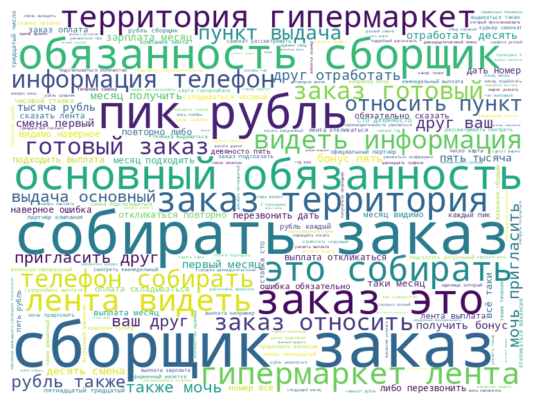

In [ ]:
# Объединение текста из всех строк в одну переменную
all_text = ' '.join(new_clear['text'].tolist())
all_text = all_text.lower()

# Токенизация, лемматизация и фильтрация стоп-слов для всего текста
all_tokens = tokenize_lemmatize_and_filter(all_text)

# Объединение токенов для создания облака слов
text_for_wordcloud = ' '.join(all_tokens)

WC(text_for_wordcloud)

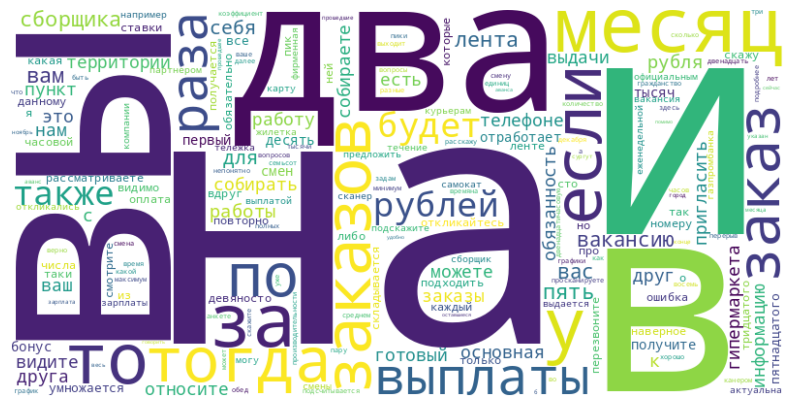

In [ ]:
operator_text = ' '.join(new_clear.query('spk == 0')['text'])
function_worldcloud(operator_text)

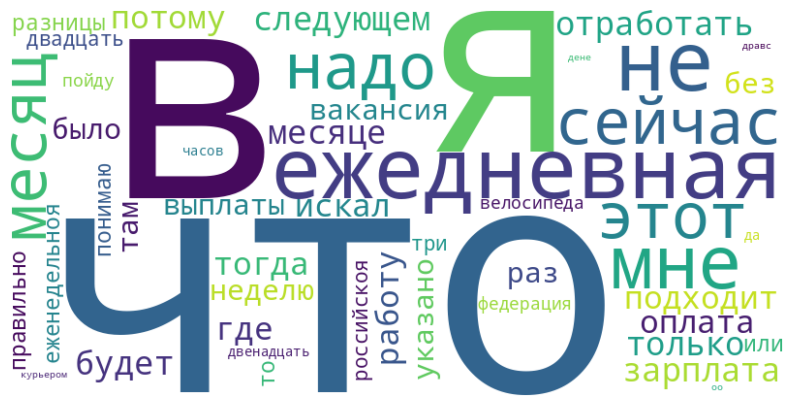

In [ ]:
applicant_text = ' '.join(new_clear.query('spk == 1')['text'])
function_worldcloud(applicant_text)

##ПОИСК по списку ключевых понятий. извлеченных из произвольного текста

**В этой части разбираю задачу - создать алгоритм. который на основе произвольного текста ( в данном примере - части чек-листа заказчика) выделят токены, проводит векторный поиск и оченивает совпадение.**

Можно извлечь список ключей из текста описания запроса пользователя: токенизация, лемматизация, очистка (стоп-слова и регулярки, стимер)


In [ ]:
# testtext = " Как вас зовут Ищете ли работу В каком городе проживаете Сколько вам лет Гражданство РФ или нет Есть ли судимости."

In [ ]:
# произвольный текст (чек лист заказчика)
testtext = " Рекрутер поздоровался и представился Уточнил лидовые вопросы Назвал адрес склада Назвал вакансию, обязанности, график, зарплату в смену, периодичность выплат, стажировку. В случае если не подошло предложение, предложили ли альтернативуНазвал список документов для трудоустройства.Отработал возражение, если оно было.Запросил ФИО и ватсап ."

In [ ]:
test_tokens = tokenize_lemmatize_and_filter(testtext)

токенизация, лемматизация, очистка

In [ ]:
test_tokens

['рекрутер',
 'поздороваться',
 'представиться',
 'уточнить',
 'лидовыя',
 'вопрос',
 'назвать',
 'адрес',
 'склад',
 'назвать',
 'вакансия',
 'обязанность',
 'график',
 'зарплата',
 'смена',
 'периодичность',
 'выплата',
 'стажировка',
 'случай',
 'подойти',
 'предложение',
 'предложить',
 'альтернативуназвать',
 'список',
 'документ',
 'возражение',
 'оно',
 'фио',
 'ватсап']

сначала выделяем токены из произвольного текста, потом лемматизируем из (оставется основная часть слова, приставки, окончания итд - отсекаются

для русского языка лучше подходят специализированные стимеры (Porter.stem, SnowballStemmer, ), стандартныз хуже

In [ ]:
keys=test_tokens

In [ ]:
#text=all_text

In [ ]:
#import nltk.stem.snowball

In [ ]:
from nltk.stem.snowball import SnowballStemmer
stemmer = SnowballStemmer('russian')
#[(word, stemmer.stem(word)) for word in word_tokenize(text)][:30] (TypeError: cannot use a string pattern on a bytes-like object)

In [ ]:
[(word, stemmer.stem(word)) for word in keys][:100]

[('рекрутер', 'рекрутер'),
 ('поздороваться', 'поздорова'),
 ('представиться', 'представ'),
 ('уточнить', 'уточн'),
 ('лидовыя', 'лидовы'),
 ('вопрос', 'вопрос'),
 ('назвать', 'назва'),
 ('адрес', 'адрес'),
 ('склад', 'склад'),
 ('назвать', 'назва'),
 ('вакансия', 'ваканс'),
 ('обязанность', 'обязан'),
 ('график', 'график'),
 ('зарплата', 'зарплат'),
 ('смена', 'смен'),
 ('периодичность', 'периодичн'),
 ('выплата', 'выплат'),
 ('стажировка', 'стажировк'),
 ('случай', 'случа'),
 ('подойти', 'подойт'),
 ('предложение', 'предложен'),
 ('предложить', 'предлож'),
 ('альтернативуназвать', 'альтернативуназва'),
 ('список', 'список'),
 ('документ', 'документ'),
 ('возражение', 'возражен'),
 ('оно', 'он'),
 ('фио', 'фи'),
 ('ватсап', 'ватсап')]

слова из текста и то, как их возвращает стиммер

In [ ]:
from_text = [(word, stemmer.stem(word)) for word in keys]

In [ ]:
data_stim_len = len(from_text)
print("количество токенов, извлеченных из текста описания", data_stim_len)

количество токенов, извлеченных из текста описания 29


In [ ]:
# sword = Porter.stem(word)

In [ ]:
# word = ('цветочный')

In [ ]:
# print(sword)

In [ ]:
#функция, которая находит токены совпадающие со списком ключевых
def keys_finder(cell, from_text=keys):
    matched_keys_list=[]
    for i in from_text:
        i = stemmer.stem(i)
        pattern = i
        if re.search(pattern, cell.lower()):
            matched_keys_list.append(i)
    # else: matched_keys_list.append('offtop')
    #else: matched_keys_list ='offtop'
    return matched_keys_list

In [ ]:
#применим нашу функцию с поиском скиллов на весь столбец, а результат появится в новом столбце
new_clear['keys_clear'] = new_clear['text'].apply(lambda x: keys_finder(x))

In [ ]:
# new_clear['keys_clear'].value_counts()

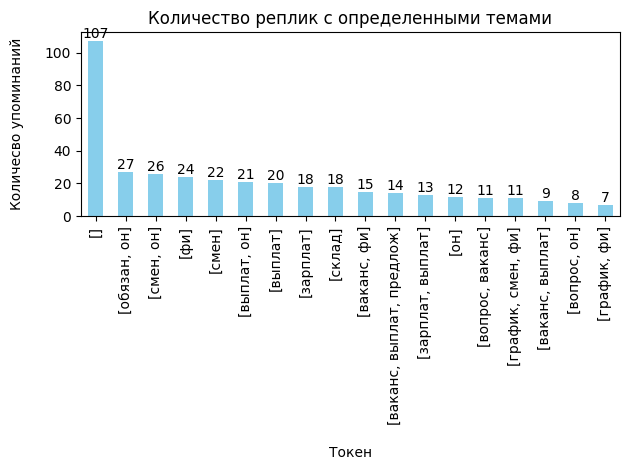

In [ ]:
# Создадим график

features_counts = new_clear['keys_clear'].value_counts()
features_counts.plot(kind='bar', color='skyblue')

plt.title('Количество реплик с определенными темами')
plt.xlabel('Токен', labelpad=15)
plt.ylabel('Количесво упоминаний', labelpad=15)

plt.xticks(rotation=90)
plt.gca().margins(x=2)

for i, val in enumerate(features_counts):
    plt.text(i, val, str(val), ha='center', va='bottom')

plt.tight_layout()
plt.show()

###Расчет метрики оценки интервью

In [ ]:
data_find_len = (new_clear['keys_clear']).count()
print("количество размеченных реплик", data_find_len)

количество размеченных реплик 383


In [ ]:
empty_list = []

In [ ]:

len= 0
for color in new_clear['keys_clear']:
    if color == empty_list:
        #  print('Элемент присутствует в списке!')
        len+=1
# Вывод: Элемент присутствует в списке!
print("количество случав, когда тема реплики не определяется как нужная по заданию", len)

количество случав, когда тема реплики не определяется как нужная по заданию 107


In [ ]:
print('метрика отражающая совпадение текста интерью с задачей по 10-ти балльной шкале')
print ()
print ()
print (round(((data_find_len - len)/data_find_len)*10))

метрика отражающая совпадение текста интерью с задачей по 10-ти балльной шкале


7


In [ ]:
# new_clear.info()

In [ ]:
# new_clear.sample(5)

###Operator query


In [ ]:
opdata=new_clear.query('spk == 0')

In [ ]:
display(opdata)

,spk,text,emotion,emotion_audio,end,part,word,lemma,start,keys_clear
0,0,здравствуйте,speech,neutral,4.500000,ГЛАГОЛ,здравствуйте,здравствовать,3.500,[]
1,0,меня зовут асельм,neutral,neutral,5.500000,МЕСТОИМЕНИЕ,меня,я,5.000,[]
2,0,меня зовут асельм,neutral,neutral,6.000000,ГЛАГОЛ,зовут,звать,5.500,[]
3,0,меня зовут асельм,neutral,neutral,6.500000,СУЩЕСТВИТЕЛЬНОЕ,асельм,асельм,6.000,[]
5,0,официальным партнером компании лента вы отклик...,neutral,neutral,7.133333,ПРИЛАГАТЕЛЬНОЕ,официальным,официальный,6.700,"[ваканс, фи]"
...,...,...,...,...,...,...,...,...,...,...
378,0,хорошо,positive,neutral,200.700000,ПРИЛАГАТЕЛЬНОЕ,хорошо,хороший,200.300,[]
379,0,всего доброго до свидания,speech,positive,201.425000,МЕСТОИМЕНИЕ,всего,всего,201.100,[]
380,0,всего доброго до свидания,speech,positive,201.750000,ПРИЛАГАТЕЛЬНОЕ,доброго,добрый,201.425,[]
381,0,всего доброго до свидания,speech,positive,202.075000,ПРЕДЛОГ,до,до,201.750,[]


In [ ]:
opdata_df = pd.DataFrame(data=opdata)

In [ ]:
opdata_df

,spk,text,emotion,emotion_audio,end,part,word,lemma,start,keys_clear
0,0,здравствуйте,speech,neutral,4.500000,ГЛАГОЛ,здравствуйте,здравствовать,3.500,[]
1,0,меня зовут асельм,neutral,neutral,5.500000,МЕСТОИМЕНИЕ,меня,я,5.000,[]
2,0,меня зовут асельм,neutral,neutral,6.000000,ГЛАГОЛ,зовут,звать,5.500,[]
3,0,меня зовут асельм,neutral,neutral,6.500000,СУЩЕСТВИТЕЛЬНОЕ,асельм,асельм,6.000,[]
5,0,официальным партнером компании лента вы отклик...,neutral,neutral,7.133333,ПРИЛАГАТЕЛЬНОЕ,официальным,официальный,6.700,"[ваканс, фи]"
...,...,...,...,...,...,...,...,...,...,...
378,0,хорошо,positive,neutral,200.700000,ПРИЛАГАТЕЛЬНОЕ,хорошо,хороший,200.300,[]
379,0,всего доброго до свидания,speech,positive,201.425000,МЕСТОИМЕНИЕ,всего,всего,201.100,[]
380,0,всего доброго до свидания,speech,positive,201.750000,ПРИЛАГАТЕЛЬНОЕ,доброго,добрый,201.425,[]
381,0,всего доброго до свидания,speech,positive,202.075000,ПРЕДЛОГ,до,до,201.750,[]


In [ ]:
opdata_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 325 entries, 0 to 382
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   spk            325 non-null    int64  
 1   text           325 non-null    object 
 2   emotion        325 non-null    object 
 3   emotion_audio  325 non-null    object 
 4   end            325 non-null    float64
 5   part           325 non-null    object 
 6   word           325 non-null    object 
 7   lemma          325 non-null    object 
 8   start          325 non-null    float64
 9   keys_clear     325 non-null    object 
dtypes: float64(2), int64(1), object(7)
memory usage: 27.9+ KB


In [ ]:
operator_text_data = new_clear.query('spk == 0')['text']

In [ ]:
operator_text_data.info()

<class 'pandas.core.series.Series'>
Index: 325 entries, 0 to 382
Series name: text
Non-Null Count  Dtype 
--------------  ----- 
325 non-null    object
dtypes: object(1)
memory usage: 5.1+ KB


In [ ]:
operator_text_data


,text
0,здравствуйте
1,меня зовут асельм
2,меня зовут асельм
3,меня зовут асельм
5,официальным партнером компании лента вы отклик...
...,...
378,хорошо
379,всего доброго до свидания
380,всего доброго до свидания
381,всего доброго до свидания


In [ ]:
operator_text_data = pd.DataFrame(data=operator_text_data)

In [ ]:
#применим нашу функцию с поиском скиллов на весь столбец, а результат появится в новом столбце
operator_text_data['keys_clear'] = operator_text_data['text'].apply(lambda x: keys_finder(x))

In [ ]:
operator_text_data['keys_clear'].value_counts()

,count
keys_clear,
[],75
"[обязан, он]",27
"[смен, он]",26
[фи],24
[смен],22
"[выплат, он]",21
[выплат],20
[склад],18
"[ваканс, фи]",15


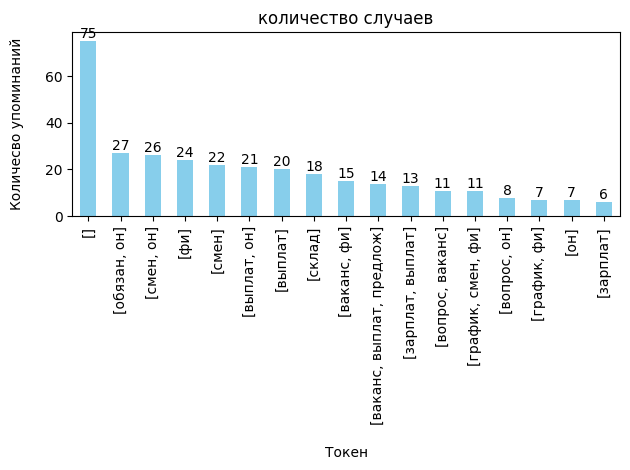

In [ ]:
# Создадим график

features_counts = operator_text_data['keys_clear'].value_counts()
features_counts.plot(kind='bar', color='skyblue')

plt.title('количество случаев')
plt.xlabel('Токен', labelpad=15)
plt.ylabel('Количесво упоминаний', labelpad=15)

plt.xticks(rotation=90)
plt.gca().margins(x=2)

for i, val in enumerate(features_counts):
    plt.text(i, val, str(val), ha='center', va='bottom')

plt.tight_layout()
plt.show()

###Расчет метрики оценки интервью только по текстам оператора

In [ ]:
data_find_len1 = (operator_text_data['keys_clear']).count()
print("количество размеченных реплик", data_find_len1)

количество размеченных реплик 325


In [ ]:
empty_list = []

In [ ]:

len1= 0
for color in operator_text_data['keys_clear']:
    if color == empty_list:
        #  print('Элемент присутствует в списке!')
        len1+=1
# Вывод: Элемент присутствует в списке!
print("количество случав, когда тема реплики не определяется как нужная по заданию", len1)

количество случав, когда тема реплики не определяется как нужная по заданию 75


In [ ]:
print('метрика отражающая совпадение текста интерью с задачей по 10-ти балльной шкале')
print ()
print ()
res_1= (round(((data_find_len1 - len1)/data_find_len1)*10))
print (res_1)

метрика отражающая совпадение текста интерью с задачей по 10-ти балльной шкале


8


In [ ]:
# totalrange = round(10*((datalen-offtop)/datalen))
# print(totalrange)
if res_1 < 5:
    print ('alert! ALERT!!!!')
if res_1 >= 5:
    print ('good result')

good result
